## To perform time evolution and measure three different spin components (single spin)

As we saw earlier, measuring spin in axes other than the z will require some rotations to be performed. In this file, a circuit is demonstrated to perform the same. We start by performing the time evolution operator.

In [22]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt


tau = np.pi/3

# 1. State preparation: U3(tau, π/2, -π/2)|0>
qc = QuantumCircuit(1)
qc.u(tau, np.pi/3, -np.pi/4, 0)

state = Statevector.from_instruction(qc)

# 2. Sx measurement basis
qc_x = QuantumCircuit(1,1)

qc_x.u(tau, np.pi/3, -np.pi/4,  0)
qc_x.ry(-np.pi/2, 0)

state_x = Statevector.from_instruction(qc_x)

# 3. Sy measurement basis
qc_y = QuantumCircuit(1,1)

qc_y.u(tau, np.pi/3, -np.pi/4, 0)
qc_y.rz(-np.pi/2, 0)
qc_y.ry(-np.pi/2, 0)

state_y = Statevector.from_instruction(qc_y)


# 4. Sz measurement basis
qc_z = QuantumCircuit(1,1)

qc_z.u(tau, np.pi/3, -np.pi/4, 0)

state_z = Statevector.from_instruction(qc_z)

Prepared State


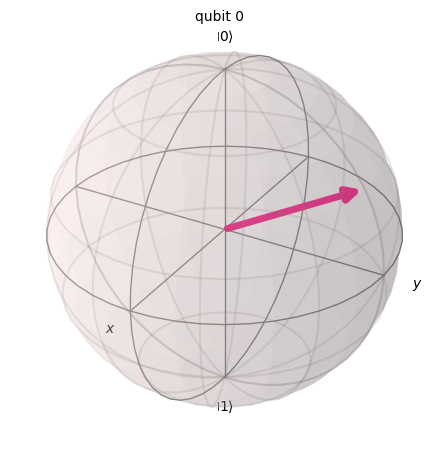

Sx


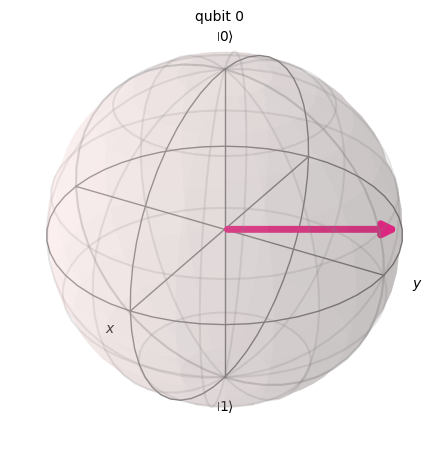

Sy


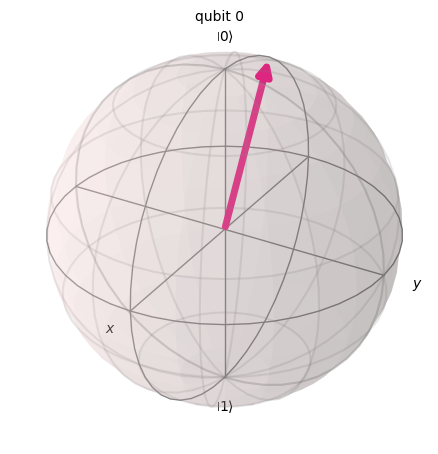

Sz


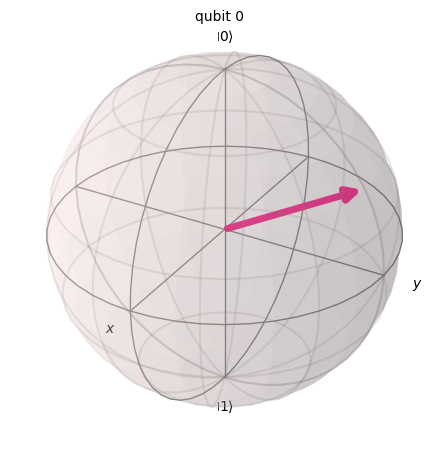

In [15]:
states = [
    ("Prepared State", state),
    ("Sx", state_x),
    ("Sy", state_y),
    ("Sz", state_z),
]

for title, state in states:
    print(title)
    display(plot_bloch_multivector(state))

In [23]:
# Measurements

qc_x.measure_all()
qc_y.measure_all()
qc_z.measure_all()

# Run on a Simulator
from qiskit_aer import AerSimulator
from qiskit import transpile

backend = AerSimulator()
shots = 500

circuits = [qc_x, qc_y, qc_z]

job = backend.run(
    transpile(circuits, backend),
    shots=shots
)

result = job.result()

counts_x = result.get_counts(0)
counts_y = result.get_counts(1)
counts_z = result.get_counts(2)

# Display the results
print("Counts for Sx measurement basis:", counts_x)
print("Counts for Sy measurement basis:", counts_y)
print("Counts for Sz measurement basis:", counts_z)





Counts for Sx measurement basis: {'0 0': 370, '1 0': 130}
Counts for Sy measurement basis: {'0 0': 419, '1 0': 81}
Counts for Sz measurement basis: {'1 0': 126, '0 0': 374}
